# Comprehensive Sampling Rate Analysis

This notebook performs a full analysis of the sampling done in the CSV file.
It includes timestamp cleaning, comprehensive sampling statistics, jitter analysis,
gap detection, spectral analysis, and detailed visualizations.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import seaborn as sns
from scipy.fft import fft, fftfreq
from pathlib import Path



## 1. DATA LOADING AND EXPLORATION


In [3]:

cwd = Path.cwd()
project_root = cwd if (cwd / "data").exists() else cwd.parent
csv_file = project_root / "data" / "climb_20260625_105842_81af6997.csv"

if not csv_file.exists():
    raise FileNotFoundError(f"CSV not found: {csv_file}")

# Skip metadata section
df = pd.read_csv(
    csv_file,
    sep=",",
    quotechar='"',
    comment="#",
    engine="python"
)

df.columns = [c.strip().strip('"') for c in df.columns]
print(df.head())
print(df["Sensor"].unique())

print("=" * 70)
print("DATA OVERVIEW")
print("=" * 70)
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nDataframe shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:\n{df.describe()}")


   Time(ms) Sensor  Accel.X(m/s²)  Accel.Y(m/s²)  Accel.Z(m/s²)  \
0       102  fused       0.000000       0.000000       0.000000   
1       124  fused      -0.331404       0.300564       9.852358   
2       144  fused      -0.398478       0.870693       9.663114   
3       167  fused      -0.372128       1.347397       9.730187   
4       200  fused      -0.472739       0.501786       9.766120   

   Gyro.X(rad/s)  Gyro.Y(rad/s)  Gyro.Z(rad/s)  Heart(bpm)  Pressure(hPa)  \
0            0.0            0.0            0.0         0.0            0.0   
1            0.0            0.0            0.0         0.0            0.0   
2            0.0            0.0            0.0         0.0            0.0   
3            0.0            0.0            0.0         0.0            0.0   
4            0.0            0.0            0.0         0.0            0.0   

   Altitude(m)  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  
['fused']
DATA OVERVIEW

Column 

,Time(ms),Sensor,Accel.X(m/s²),Accel.Y(m/s²),Accel.Z(m/s²),Gyro.X(rad/s),Gyro.Y(rad/s),Gyro.Z(rad/s),Heart(bpm),Pressure(hPa),Altitude(m)
0,102,fused,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,124,fused,-0.331404,0.300564,9.852358,0.0,0.0,0.0,0.0,0.0,0.0
2,144,fused,-0.398478,0.870693,9.663114,0.0,0.0,0.0,0.0,0.0,0.0
3,167,fused,-0.372128,1.347397,9.730187,0.0,0.0,0.0,0.0,0.0,0.0
4,200,fused,-0.472739,0.501786,9.766120,0.0,0.0,0.0,0.0,0.0,0.0



Data types:
Time(ms)           int64
Sensor            object
Accel.X(m/s²)    float64
Accel.Y(m/s²)    float64
Accel.Z(m/s²)    float64
Gyro.X(rad/s)    float64
Gyro.Y(rad/s)    float64
Gyro.Z(rad/s)    float64
Heart(bpm)       float64
Pressure(hPa)    float64
Altitude(m)      float64
dtype: object

Basic statistics:
           Time(ms)  Accel.X(m/s²)  Accel.Y(m/s²)  Accel.Z(m/s²)  \
count    831.000000     831.000000     831.000000     831.000000   
mean    8405.221420       0.757414      -6.788598       5.082434   
std     4800.854196       1.697049       4.562856       4.151816   
min      102.000000     -27.223288     -37.452515     -41.703594   
25%     4254.500000      -0.270319      -9.760536       2.476613   
50%     8405.000000       1.204111      -8.876596       4.668496   
75%    12555.000000       1.337062      -0.607331       9.346908   
max    16705.000000      12.853428      14.220815      28.379154   

       Gyro.X(rad/s)  Gyro.Y(rad/s)  Gyro.Z(rad/s)  Heart(bpm)  Pr

## 2. TIMESTAMP CLEANING AND PREPARATION


In [4]:

# Auto-detect timestamp column
time_col = None
for col in df.columns:
    if 'time' in col.lower() or 'timestamp' in col.lower():
        time_col = col
        break

if time_col is None:
    # If no time column found, try the first column
    time_col = df.columns[0]
    print(f"Warning: Could not find 'time' or 'timestamp' column. Using first column: '{time_col}'")
else:
    print(f"Detected timestamp column: '{time_col}'")

def prepare_timing_vectors(dataframe, raw_time_col):
    """Create cleaned timestamp arrays so downstream cells can run independently."""
    data = dataframe.copy()
    data["Time(ms)"] = pd.to_numeric(data[raw_time_col], errors="coerce")
    initial_rows = len(data)
    data = data.dropna(subset=["Time(ms)"])
    dropped_rows = initial_rows - len(data)

    print(f"Initial rows: {initial_rows}")
    print(f"Rows with invalid timestamps: {dropped_rows}")
    print(f"Rows after cleaning: {len(data)}")

    data = data.sort_values("Time(ms)").reset_index(drop=True)
    duplicates = data.duplicated(subset="Time(ms)").sum()
    print(f"Duplicate timestamps removed: {duplicates}")
    data = data.drop_duplicates(subset="Time(ms)", keep="first")

    t_seconds = data["Time(ms)"].to_numpy(dtype=float) / 1000.0
    dt_all = np.diff(t_seconds)
    dt_positive = dt_all[dt_all > 0]

    return data, t_seconds, dt_all, dt_positive


df, t, dt, dt_valid = prepare_timing_vectors(df, time_col)

print(f"\nFinal sample count: {len(t)}")
print(f"Valid intervals (>0): {len(dt_valid)}")
print(f"Zero or negative intervals: {len(dt) - len(dt_valid)}")


Detected timestamp column: 'Time(ms)'
Initial rows: 831
Rows with invalid timestamps: 0
Rows after cleaning: 831
Duplicate timestamps removed: 1

Final sample count: 830
Valid intervals (>0): 829
Zero or negative intervals: 0


In [5]:

# Notebook recovery block: rebuild core timing arrays if cells run out of order.
if "dt_valid" not in globals() or len(dt_valid) == 0:
    if "df" not in globals():
        cwd = Path.cwd()
        project_root = cwd if (cwd / "data").exists() else cwd.parent
        csv_file = project_root / "data" / "climb_20260621_134200_3327fd0a.csv"
        if not csv_file.exists():
            raise FileNotFoundError(f"CSV not found: {csv_file}")
        df = pd.read_csv(csv_file, sep=",", quotechar='"', comment="#", engine="python")
        df.columns = [c.strip().strip('"') for c in df.columns]

    if "time_col" not in globals() or time_col not in df.columns:
        time_candidates = [c for c in df.columns if "time" in c.lower() or "timestamp" in c.lower()]
        time_col = time_candidates[0] if time_candidates else df.columns[0]

    df, t, dt, dt_valid = prepare_timing_vectors(df, time_col)
    print("Recovered timing vectors: df, t, dt, dt_valid")


## 3. CORE SAMPLING STATISTICS


In [7]:

duration = t[-1] - t[0]
n_samples = len(t)
overall_fs = (n_samples - 1) / duration

print("=" * 70)
print("SAMPLING STATISTICS")
print("=" * 70)

print(f"\nTemporal Coverage:")
print(f"  Total samples: {n_samples}")
print(f"  Total duration: {duration:.3f} seconds ({duration/60:.2f} minutes)")
print(f"  Start time: {t[0]:.3f} s")
print(f"  End time: {t[-1]:.3f} s")

print(f"\nSampling Rate:")
print(f"  Overall fs: {overall_fs:.2f} Hz")
print(f"  Median fs: {1/np.median(dt_valid):.2f} Hz")
print(f"  Mean fs: {1/np.mean(dt_valid):.2f} Hz")
print(f"  Mode fs: {1/stats.mode(dt_valid, keepdims=True).mode[0]:.2f} Hz")

print(f"\nTime Interval Statistics (in ms):")
dt_ms = dt_valid * 1000
print(f"  Mean: {np.mean(dt_ms):.4f}")
print(f"  Median: {np.median(dt_ms):.4f}")
print(f"  Std Dev: {np.std(dt_ms):.4f}")
print(f"  Variance: {np.var(dt_ms):.6f}")
print(f"  Min: {np.min(dt_ms):.4f}")
print(f"  Max: {np.max(dt_ms):.4f}")
print(f"  Range: {np.max(dt_ms) - np.min(dt_ms):.4f}")
print(f"  Q1 (25%): {np.percentile(dt_ms, 25):.4f}")
print(f"  Q3 (75%): {np.percentile(dt_ms, 75):.4f}")
print(f"  IQR: {np.percentile(dt_ms, 75) - np.percentile(dt_ms, 25):.4f}")


SAMPLING STATISTICS

Temporal Coverage:
  Total samples: 830
  Total duration: 16.603 seconds (0.28 minutes)
  Start time: 0.102 s
  End time: 16.705 s

Sampling Rate:
  Overall fs: 49.93 Hz
  Median fs: 50.00 Hz
  Mean fs: 49.93 Hz
  Mode fs: 50.00 Hz

Time Interval Statistics (in ms):
  Mean: 20.0277
  Median: 20.0000
  Std Dev: 2.4809
  Variance: 6.154839
  Min: 3.0000
  Max: 38.0000
  Range: 35.0000
  Q1 (25%): 19.0000
  Q3 (75%): 21.0000
  IQR: 2.0000


## 4. JITTER AND TIMING STABILITY ANALYSIS


In [8]:

# Jitter analysis
mean_dt = np.mean(dt_valid)
jitter = dt_valid - mean_dt
jitter_ms = jitter * 1000
jitter_pct = (np.abs(jitter) / mean_dt) * 100

print("=" * 70)
print("JITTER ANALYSIS")
print("=" * 70)

print(f"\nJitter Statistics (deviation from mean interval):")
print(f"  Mean jitter: {np.mean(jitter_ms):.4f} ms (should be ~0)")
print(f"  Jitter std dev: {np.std(jitter_ms):.4f} ms")
print(f"  Jitter range: {np.min(jitter_ms):.4f} to {np.max(jitter_ms):.4f} ms")
print(f"  Mean absolute jitter: {np.mean(np.abs(jitter_ms)):.4f} ms")

print(f"\nJitter as % of mean interval:")
print(f"  Mean percentage jitter: {np.mean(jitter_pct):.2f}%")
print(f"  Max percentage jitter: {np.max(np.abs(jitter_pct)):.2f}%")
print(f"  Std dev of percentage jitter: {np.std(np.abs(jitter_pct)):.2f}%")

# Phase deviation (cumulative timing error)
phase_error = np.cumsum(jitter)
phase_error_ms = phase_error * 1000

print(f"\nPhase Deviation (cumulative timing error):")
print(f"  Max deviation from expected time: {np.max(np.abs(phase_error_ms)):.4f} ms")
print(f"  Final cumulative error: {phase_error_ms[-1]:.4f} ms")


JITTER ANALYSIS

Jitter Statistics (deviation from mean interval):
  Mean jitter: 0.0000 ms (should be ~0)
  Jitter std dev: 2.4809 ms
  Jitter range: -17.0277 to 17.9723 ms
  Mean absolute jitter: 1.3574 ms

Jitter as % of mean interval:
  Mean percentage jitter: 6.78%
  Max percentage jitter: 89.74%
  Std dev of percentage jitter: 10.37%

Phase Deviation (cumulative timing error):
  Max deviation from expected time: 20.5235 ms
  Final cumulative error: 0.0000 ms


## 5. OUTLIER AND GAP DETECTION


In [9]:

# Detect outliers (intervals significantly different from median)
median_dt = np.median(dt_valid)
outlier_threshold = median_dt * 1.5  # 50% above median
outliers = dt_valid > outlier_threshold
n_outliers = np.sum(outliers)

print("=" * 70)
print("OUTLIER AND GAP DETECTION")
print("=" * 70)

print(f"\nOutlier Detection (intervals > {outlier_threshold*1000:.4f} ms):")
print(f"  Number of outliers: {n_outliers}")
print(f"  Percentage of intervals: {(n_outliers/len(dt_valid))*100:.2f}%")

if n_outliers > 0:
    outlier_indices = np.where(outliers)[0]
    print(f"  Outlier intervals (ms): {dt_valid[outliers]*1000}")
    print(f"  Indices: {outlier_indices[:10]}{'...' if n_outliers > 10 else ''}")

# Detect gaps (much larger intervals, potential missed samples)
gap_threshold = median_dt * 3  # 3x median
gaps = dt_valid > gap_threshold
n_gaps = np.sum(gaps)

print(f"\nGap Detection (intervals > {gap_threshold*1000:.4f} ms):")
print(f"  Number of gaps: {n_gaps}")
print(f"  Percentage of intervals: {(n_gaps/len(dt_valid))*100:.4f}%")

if n_gaps > 0:
    gap_indices = np.where(gaps)[0]
    print(f"  Gap intervals (ms): {dt_valid[gaps]*1000}")
    print(f"  Indices: {gap_indices[:10]}{'...' if n_gaps > 10 else ''}")
    print(f"  Implied missed samples per gap: {(dt_valid[gaps]/median_dt - 1).astype(int)}")


OUTLIER AND GAP DETECTION

Outlier Detection (intervals > 30.0000 ms):
  Number of outliers: 7
  Percentage of intervals: 0.84%
  Outlier intervals (ms): [33. 31. 30. 38. 33. 35. 32.]
  Indices: [  3  42 253 627 699 706 712]

Gap Detection (intervals > 60.0000 ms):
  Number of gaps: 0
  Percentage of intervals: 0.0000%


## 6. FREQUENCY DOMAIN ANALYSIS


In [10]:

# FFT analysis of time intervals
if "dt_valid" not in globals() or len(dt_valid) == 0:
    df, t, dt, dt_valid = prepare_timing_vectors(df, time_col)
if "mean_dt" not in globals():
    mean_dt = np.mean(dt_valid)

N = len(dt_valid)
# We're analyzing the interval variation, not a signal
fft_result = fft(dt_valid - mean_dt)
freqs = fftfreq(N, d=1)[:N//2]
power = np.abs(fft_result[:N//2])**2

print("=" * 70)
print("FREQUENCY DOMAIN ANALYSIS")
print("=" * 70)

print(f"\nPeriodic Components in Sampling Interval:")
# Find dominant frequencies
dominant_indices = np.argsort(power)[-5:][::-1]
print(f"  Top 5 dominant frequency components:")
for rank, idx in enumerate(dominant_indices, 1):
    if freqs[idx] > 0:
        print(f"    {rank}. Frequency: {freqs[idx]:.6f} Hz, Power: {power[idx]:.4f}")

# Autocorrelation
dt_detrended = dt_valid - mean_dt
autocorr = np.correlate(dt_detrended, dt_detrended, mode='full')
autocorr = autocorr[len(autocorr)//2:]
autocorr = autocorr / autocorr[0]

print(f"\nAutocorrelation Analysis:")
lag1_value = f"{autocorr[1]:.4f}" if len(autocorr) > 1 else "N/A"
lag10_value = f"{autocorr[10]:.4f}" if len(autocorr) > 10 else "N/A"
print(f"  Autocorr at lag 1: {lag1_value}")
print(f"  Autocorr at lag 10: {lag10_value}")


FREQUENCY DOMAIN ANALYSIS

Periodic Components in Sampling Interval:
  Top 5 dominant frequency components:
    1. Frequency: 0.396864 Hz, Power: 0.0349
    2. Frequency: 0.435464 Hz, Power: 0.0347
    3. Frequency: 0.365501 Hz, Power: 0.0333
    4. Frequency: 0.379976 Hz, Power: 0.0267
    5. Frequency: 0.319662 Hz, Power: 0.0248

Autocorrelation Analysis:
  Autocorr at lag 1: -0.3360
  Autocorr at lag 10: -0.0556


## 7. VISUALIZATIONS


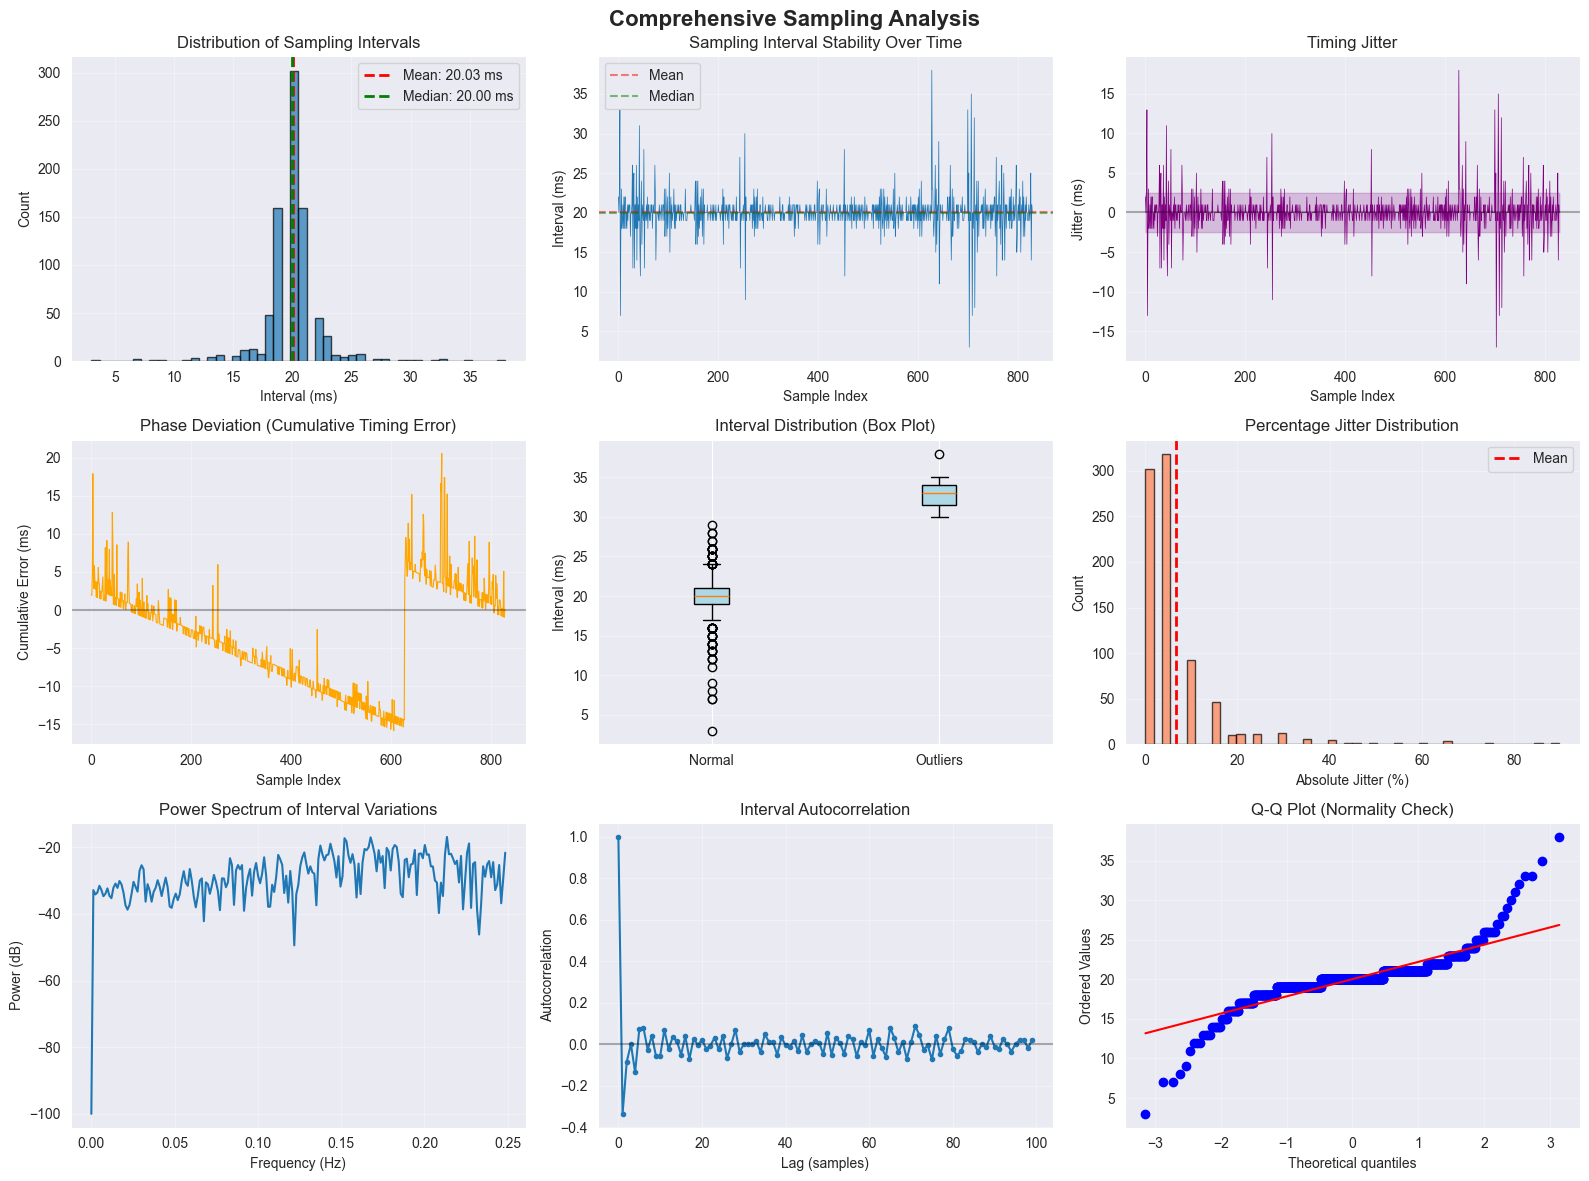

In [11]:

# Rebuild dependent arrays if this section is run directly.
required_vars = ["dt_ms", "median_dt", "jitter_ms", "jitter_pct", "phase_error_ms", "outliers", "n_outliers", "freqs", "power", "autocorr"]
if any(name not in globals() for name in required_vars):
    if "dt_valid" not in globals() or len(dt_valid) == 0:
        df, t, dt, dt_valid = prepare_timing_vectors(df, time_col)

    mean_dt = np.mean(dt_valid)
    median_dt = np.median(dt_valid)
    dt_ms = dt_valid * 1000
    jitter = dt_valid - mean_dt
    jitter_ms = jitter * 1000
    jitter_pct = (np.abs(jitter) / mean_dt) * 100
    phase_error = np.cumsum(jitter)
    phase_error_ms = phase_error * 1000

    outlier_threshold = median_dt * 1.5
    outliers = dt_valid > outlier_threshold
    n_outliers = np.sum(outliers)

    N = len(dt_valid)
    fft_result = fft(dt_valid - mean_dt)
    freqs = fftfreq(N, d=1)[:N//2]
    power = np.abs(fft_result[:N//2])**2

    dt_detrended = dt_valid - mean_dt
    autocorr = np.correlate(dt_detrended, dt_detrended, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr = autocorr / autocorr[0]

# Create a comprehensive figure with multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Comprehensive Sampling Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of intervals
ax = axes[0, 0]
ax.hist(dt_ms, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(mean_dt*1000, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_dt*1000:.2f} ms')
ax.axvline(median_dt*1000, color='g', linestyle='--', linewidth=2, label=f'Median: {median_dt*1000:.2f} ms')
ax.set_xlabel('Interval (ms)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Sampling Intervals')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Time series of intervals
ax = axes[0, 1]
ax.plot(dt_ms, linewidth=0.5)
ax.axhline(mean_dt*1000, color='r', linestyle='--', alpha=0.5, label='Mean')
ax.axhline(median_dt*1000, color='g', linestyle='--', alpha=0.5, label='Median')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Interval (ms)')
ax.set_title('Sampling Interval Stability Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Jitter over time
ax = axes[0, 2]
ax.plot(jitter_ms, linewidth=0.5, color='purple')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.fill_between(range(len(jitter_ms)), -np.std(jitter_ms), np.std(jitter_ms), alpha=0.2, color='purple')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Jitter (ms)')
ax.set_title('Timing Jitter')
ax.grid(True, alpha=0.3)

# 4. Phase deviation
ax = axes[1, 0]
ax.plot(phase_error_ms, linewidth=0.8, color='orange')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cumulative Error (ms)')
ax.set_title('Phase Deviation (Cumulative Timing Error)')
ax.grid(True, alpha=0.3)

# 5. Box plot of intervals
ax = axes[1, 1]
box_data = [dt_ms[~outliers], dt_valid[outliers]*1000] if n_outliers > 0 else [dt_ms]
bp = ax.boxplot(box_data, tick_labels=['Normal', 'Outliers'] if n_outliers > 0 else ['All'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Interval (ms)')
ax.set_title('Interval Distribution (Box Plot)')
ax.grid(True, alpha=0.3, axis='y')

# 6. Histogram of percentage jitter
ax = axes[1, 2]
ax.hist(np.abs(jitter_pct), bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(np.mean(np.abs(jitter_pct)), color='r', linestyle='--', linewidth=2, label='Mean')
ax.set_xlabel('Absolute Jitter (%)')
ax.set_ylabel('Count')
ax.set_title('Percentage Jitter Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 7. FFT Power spectrum
ax = axes[2, 0]
valid_freqs = freqs[:len(freqs)//2]
ax.plot(valid_freqs, 10*np.log10(power[:len(power)//2]+1e-10))
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('Power Spectrum of Interval Variations')
ax.grid(True, alpha=0.3)

# 8. Autocorrelation
ax = axes[2, 1]
lags = np.arange(min(100, len(autocorr)))
ax.plot(lags, autocorr[lags], 'o-', markersize=3)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Lag (samples)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Interval Autocorrelation')
ax.grid(True, alpha=0.3)

# 9. Q-Q plot for normality
ax = axes[2, 2]
stats.probplot(dt_ms, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. SUMMARY REPORT


In [12]:

print("\n" + "=" * 70)
print("FINAL SUMMARY REPORT")
print("=" * 70)

print(f"\n✓ SAMPLING COVERAGE:")
print(f"   Duration: {duration:.2f} seconds ({duration/60:.2f} minutes)")
print(f"   Samples collected: {n_samples}")
print(f"   Average sampling rate: {overall_fs:.2f} Hz")

print(f"\n✓ TIMING CONSISTENCY:")
if np.std(jitter_pct) < 1.0:
    consistency = "Excellent"
elif np.std(jitter_pct) < 2.0:
    consistency = "Good"
elif np.std(jitter_pct) < 5.0:
    consistency = "Fair"
else:
    consistency = "Poor"
print(f"   Consistency rating: {consistency}")
print(f"   Jitter std dev: {np.std(jitter_pct):.2f}%")

print(f"\n✓ DATA QUALITY:")
print(f"   Total outliers: {n_outliers} ({(n_outliers/len(dt_valid))*100:.2f}%)")
print(f"   Detected gaps: {n_gaps} ({(n_gaps/len(dt_valid))*100:.4f}%)")
print(f"   Max phase error: {np.max(np.abs(phase_error_ms)):.2f} ms")

print(f"\n✓ NORMALITY TEST:")
_, p_value = stats.normaltest(dt_ms)
is_normal = "Yes (p>{:.3f})".format(0.05) if p_value > 0.05 else "No (p<{:.3f})".format(0.05)
print(f"   Intervals normally distributed: {is_normal} (p-value: {p_value:.6f})")

print("\n" + "=" * 70)



FINAL SUMMARY REPORT

✓ SAMPLING COVERAGE:
   Duration: 16.60 seconds (0.28 minutes)
   Samples collected: 830
   Average sampling rate: 49.93 Hz

✓ TIMING CONSISTENCY:
   Consistency rating: Poor
   Jitter std dev: 10.37%

✓ DATA QUALITY:
   Total outliers: 7 (0.84%)
   Detected gaps: 0 (0.0000%)
   Max phase error: 20.52 ms

✓ NORMALITY TEST:
   Intervals normally distributed: No (p<0.050) (p-value: 0.000000)

